In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# Create folder to save all visualisations automatically
os.makedirs('visualisations', exist_ok=True)

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


In [2]:
#Load the dataset
data = pd.read_csv(r"C:\Users\Henry Bode\Downloads\chips project\QVI_data (1).csv")

# Convert DATE from string to datetime
data['DATE'] = pd.to_datetime(data['DATE'])

# Create YEARMONTH column for monthly grouping (e.g. 2019-02)
data['YEARMONTH'] = data['DATE'].dt.to_period('M')

# Define trial stores and trial period
trial_stores = [77, 86, 88]
TRIAL_START  = pd.Period('2019-02', 'M')
TRIAL_END    = pd.Period('2019-04', 'M')

# Split into pre-trial dataset (used for control store selection)
pre_trial = data[data['YEARMONTH'] < TRIAL_START]

print(f"✅ Data loaded: {data.shape[0]:,} rows, {data.shape[1]} columns")
print(f"   Date range : {data['DATE'].min().date()} → {data['DATE'].max().date()}")
print(f"   Stores     : {data['STORE_NBR'].nunique()} unique stores")
print(f"   Trial stores: {trial_stores}")

✅ Data loaded: 264,834 rows, 13 columns
   Date range : 2018-07-01 → 2019-06-30
   Stores     : 272 unique stores
   Trial stores: [77, 86, 88]


In [3]:
print("\n" + "="*60)
print("DATA EXPLORATION")
print("="*60)

print("\nColumn names:")
print(data.columns.tolist())

print("\nData types:")
print(data.dtypes)

print("\nMissing values:")
print(data.isnull().sum())

print("\nSample rows:")
print(data.head(5))

print("\nBasic statistics:")
print(data[['TOT_SALES', 'PROD_QTY']].describe().round(2))


DATA EXPLORATION

Column names:
['LYLTY_CARD_NBR', 'DATE', 'STORE_NBR', 'TXN_ID', 'PROD_NBR', 'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PACK_SIZE', 'BRAND', 'LIFESTAGE', 'PREMIUM_CUSTOMER', 'YEARMONTH']

Data types:
LYLTY_CARD_NBR               int64
DATE                datetime64[ns]
STORE_NBR                    int64
TXN_ID                       int64
PROD_NBR                     int64
PROD_NAME                   object
PROD_QTY                     int64
TOT_SALES                  float64
PACK_SIZE                    int64
BRAND                       object
LIFESTAGE                   object
PREMIUM_CUSTOMER            object
YEARMONTH                period[M]
dtype: object

Missing values:
LYLTY_CARD_NBR      0
DATE                0
STORE_NBR           0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
YEARMONTH           0
dtype: int64



In [4]:
def get_store_metrics(df):
    """
    Aggregates transaction-level data into monthly store-level metrics.

    Parameters:
        df : DataFrame — transaction data (can be full data or a subset)

    Returns:
        DataFrame with columns:
            STORE_NBR, YEARMONTH, total_sales, num_customers,
            num_txns, avg_basket
    """
    return df.groupby(['STORE_NBR', 'YEARMONTH']).agg(
        total_sales   = ('TOT_SALES',      'sum'),      # Total monthly revenue
        num_customers = ('LYLTY_CARD_NBR', 'nunique'),  # Unique customers
        num_txns      = ('TXN_ID',         'count'),    # Transaction count
        avg_basket    = ('TOT_SALES',      'mean')      # Avg spend per transaction
    ).reset_index()
# Build metrics for pre-trial and full timeline
pre_metrics = get_store_metrics(pre_trial)
all_metrics = get_store_metrics(data)

print("\n✅ Monthly metrics built.")
print(f"   Pre-trial metrics shape : {pre_metrics.shape}")
print(f"   Full metrics shape      : {all_metrics.shape}")
print("\nSample pre-trial metrics:")
print(pre_metrics.head(6))


✅ Monthly metrics built.
   Pre-trial metrics shape : (1848, 6)
   Full metrics shape      : (3169, 6)

Sample pre-trial metrics:
   STORE_NBR YEARMONTH  total_sales  num_customers  num_txns  avg_basket
0          1   2018-07        206.9             49        52    3.978846
1          1   2018-08        176.1             42        43    4.095349
2          1   2018-09        278.8             59        62    4.496774
3          1   2018-10        188.1             44        45    4.180000
4          1   2018-11        192.6             46        47    4.097872
5          1   2018-12        189.6             42        47    4.034043


In [12]:
def score_candidate(trial_store, candidate, metrics_df, metric='total_sales'):
    """
    Scores how similar a candidate store is to a trial store using:
      - 60% Pearson correlation  (do they trend the same way?)
      - 40% Magnitude match      (are they a similar size?)

    Parameters:
        trial_store  : int — the trial store number
        candidate    : int — the candidate control store number
        metrics_df   : DataFrame — pre-trial monthly metrics
        metric       : str — column to compare on (default: total_sales)

    Returns:
        float — similarity score (higher = better match)
    """
    t = metrics_df[metrics_df['STORE_NBR'] == trial_store][metric].values
    c = metrics_df[metrics_df['STORE_NBR'] == candidate][metric].values

    # Align to same number of months
    n = min(len(t), len(c))
    if n < 2:
        return -999  # Not enough data to score

    t, c = t[:n], c[:n]

    # Signal 1: Pearson correlation — how well do trends match?
    corr, _ = stats.pearsonr(t, c)

    # Signal 2: Magnitude match — how similar is the scale?
    mag = 1 - abs(t.mean() - c.mean()) / (t.mean() + 1e-9)

    # Combined weighted score
    score = 0.6 * corr + 0.4 * mag
    return round(score, 4)


def find_control_store(trial_store, metrics_df, metric='total_sales', top_n=5):
    """
    Finds the best control store for a given trial store by scoring
    all non-trial stores and returning the highest match.

    Parameters:
        trial_store : int — the trial store to find a control for
        metrics_df  : DataFrame — pre-trial monthly metrics
        metric      : str — metric to compare on
        top_n       : int — how many candidates to print

    Returns:
        int — store number of the best control match
    """
    # All stores except the 3 trial stores are candidates
    candidates = [s for s in metrics_df['STORE_NBR'].unique()
                  if s not in trial_stores]

    # Score every candidate
    scores = {
        s: score_candidate(trial_store, s, metrics_df, metric)
        for s in candidates
    }

    # Sort by score descending
    scores_df = (pd.DataFrame(scores.items(), columns=['store', 'score'])
                   .sort_values('score', ascending=False)
                   .reset_index(drop=True))

    print(f"\n  Top {top_n} control candidates for Trial Store {trial_store}:")
    print(scores_df.head(top_n).to_string(index=False))

    # Return the best match store number
    return int(scores_df.iloc[0]['store'])


# ── Run control store selection for all 3 trial stores ──────────────────────
print("\n" + "="*60)
print("CONTROL STORE SELECTION")
print("="*60)

control_map = {}
for ts in trial_stores:
    control_map[ts] = find_control_store(ts, pre_metrics)

print("\n" + "-"*40)
print("Final control store mapping:")
for ts, cs in control_map.items():
    print(f"  Trial Store {ts:>3}  →  Control Store {cs}")
print("-"*40)


CONTROL STORE SELECTION

  Top 5 control candidates for Trial Store 77:
 store  score
   233 0.9330
    50 0.8120
    41 0.7952
   265 0.7220
   167 0.7061

  Top 5 control candidates for Trial Store 86:
 store  score
   155 0.9144
   222 0.8675
   109 0.8652
   138 0.8426
   114 0.8092

  Top 5 control candidates for Trial Store 88:
 store  score
    91 0.7316
   178 0.7181
   125 0.7158
     7 0.7016
   203 0.6860

----------------------------------------
Final control store mapping:
  Trial Store  77  →  Control Store 233
  Trial Store  86  →  Control Store 155
  Trial Store  88  →  Control Store 91
----------------------------------------


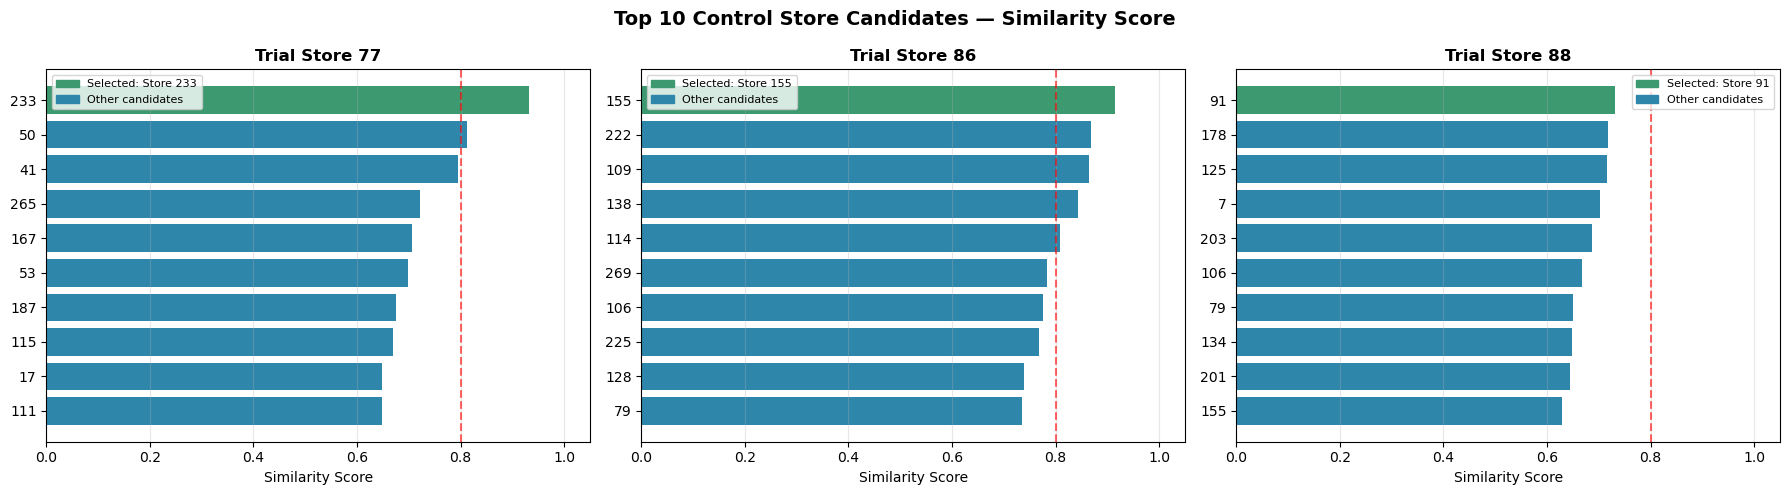

✅ Chart 1 saved: 01_control_candidate_scores.png


In [14]:
BLUE   = '#2E86AB'
ORANGE = '#E07A5F'
GREEN  = '#3D9970'
RED    = '#E63946'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Top 10 Control Store Candidates — Similarity Score',
             fontsize=14, fontweight='bold')

for i, ts in enumerate(trial_stores):
    cs = control_map[ts]
    ax = axes[i]

    candidates = [s for s in pre_metrics['STORE_NBR'].unique()
                  if s not in trial_stores]
    scores = sorted(
        [(s, score_candidate(ts, s, pre_metrics)) for s in candidates],
        key=lambda x: -x[1]
    )[:10]

    stores_list = [str(s[0]) for s in scores]
    score_vals  = [s[1] for s in scores]
    colors      = [GREEN if s[0] == cs else BLUE for s in scores]

    ax.barh(stores_list[::-1], score_vals[::-1], color=colors[::-1])
    ax.axvline(0.8, color='red', linestyle='--', alpha=0.6, label='Score = 0.8')
    ax.set_title(f'Trial Store {ts}', fontweight='bold')
    ax.set_xlabel('Similarity Score')
    ax.set_xlim(0, 1.05)

    selected_patch = mpatches.Patch(color=GREEN, label=f'Selected: Store {cs}')
    other_patch    = mpatches.Patch(color=BLUE,  label='Other candidates')
    ax.legend(handles=[selected_patch, other_patch], fontsize=8)
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('visualisations/01_control_candidate_scores.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved: 01_control_candidate_scores.png")

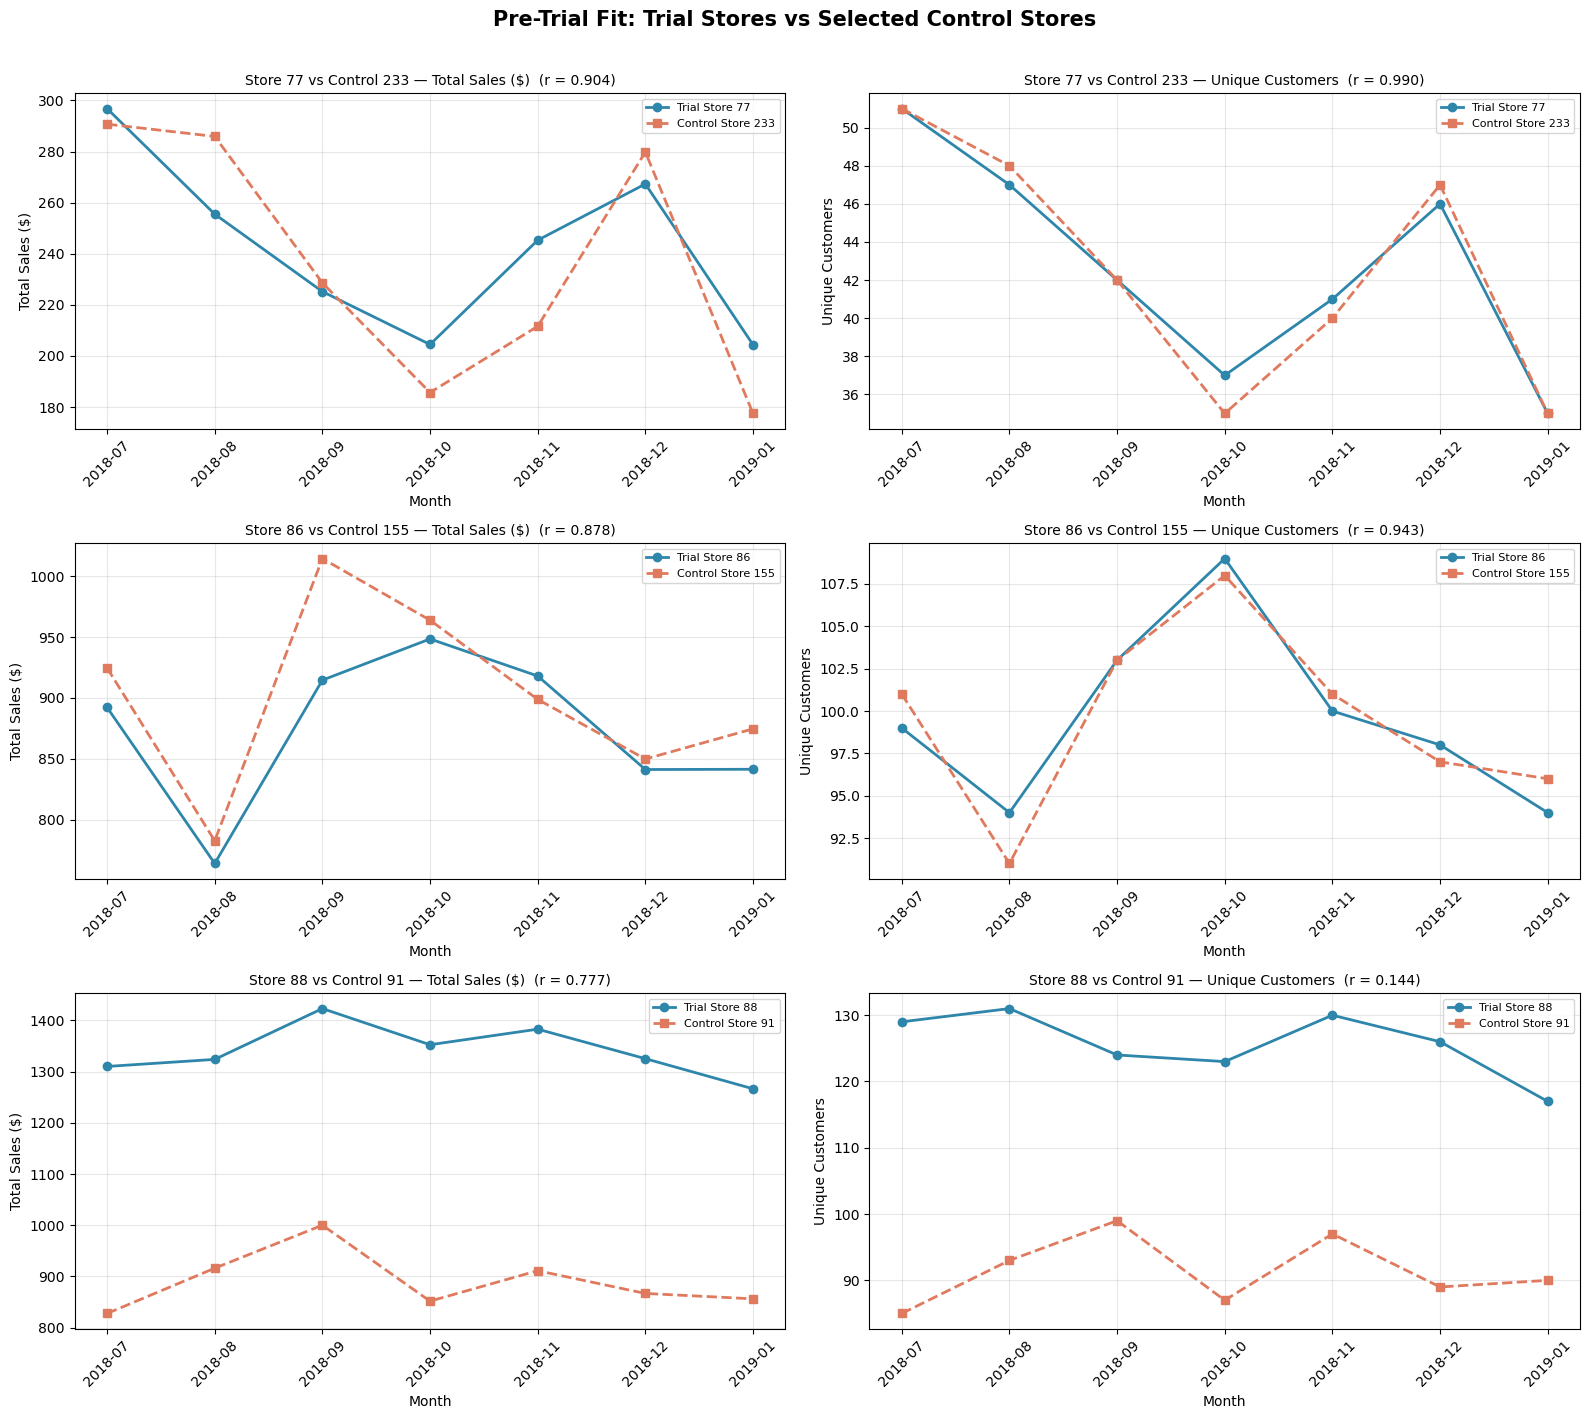

✅ Chart 2 saved: 02_pretrial_fit.png


In [16]:
metrics_to_plot = [
    ('total_sales',   'Total Sales ($)'),
    ('num_customers', 'Unique Customers')
]

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Pre-Trial Fit: Trial Stores vs Selected Control Stores',
             fontsize=15, fontweight='bold', y=1.01)

for row, ts in enumerate(trial_stores):
    cs = control_map[ts]

    for col, (metric, label) in enumerate(metrics_to_plot):
        ax = axes[row, col]

        td = pre_metrics[pre_metrics['STORE_NBR'] == ts].sort_values('YEARMONTH')
        cd = pre_metrics[pre_metrics['STORE_NBR'] == cs].sort_values('YEARMONTH')

        # Calculate correlation for display in title
        n = min(len(td), len(cd))
        corr, _ = stats.pearsonr(
            td[metric].values[:n],
            cd[metric].values[:n]
        )

        ax.plot(td['YEARMONTH'].astype(str), td[metric],
                marker='o', color=BLUE,   lw=2, label=f'Trial Store {ts}')
        ax.plot(cd['YEARMONTH'].astype(str), cd[metric],
                marker='s', color=ORANGE, lw=2, linestyle='--',
                label=f'Control Store {cs}')

        ax.set_title(f'Store {ts} vs Control {cs} — {label}  (r = {corr:.3f})',
                     fontsize=10)
        ax.set_xlabel('Month')
        ax.set_ylabel(label)
        ax.legend(fontsize=8)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('visualisations/02_pretrial_fit.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved: 02_pretrial_fit.png")


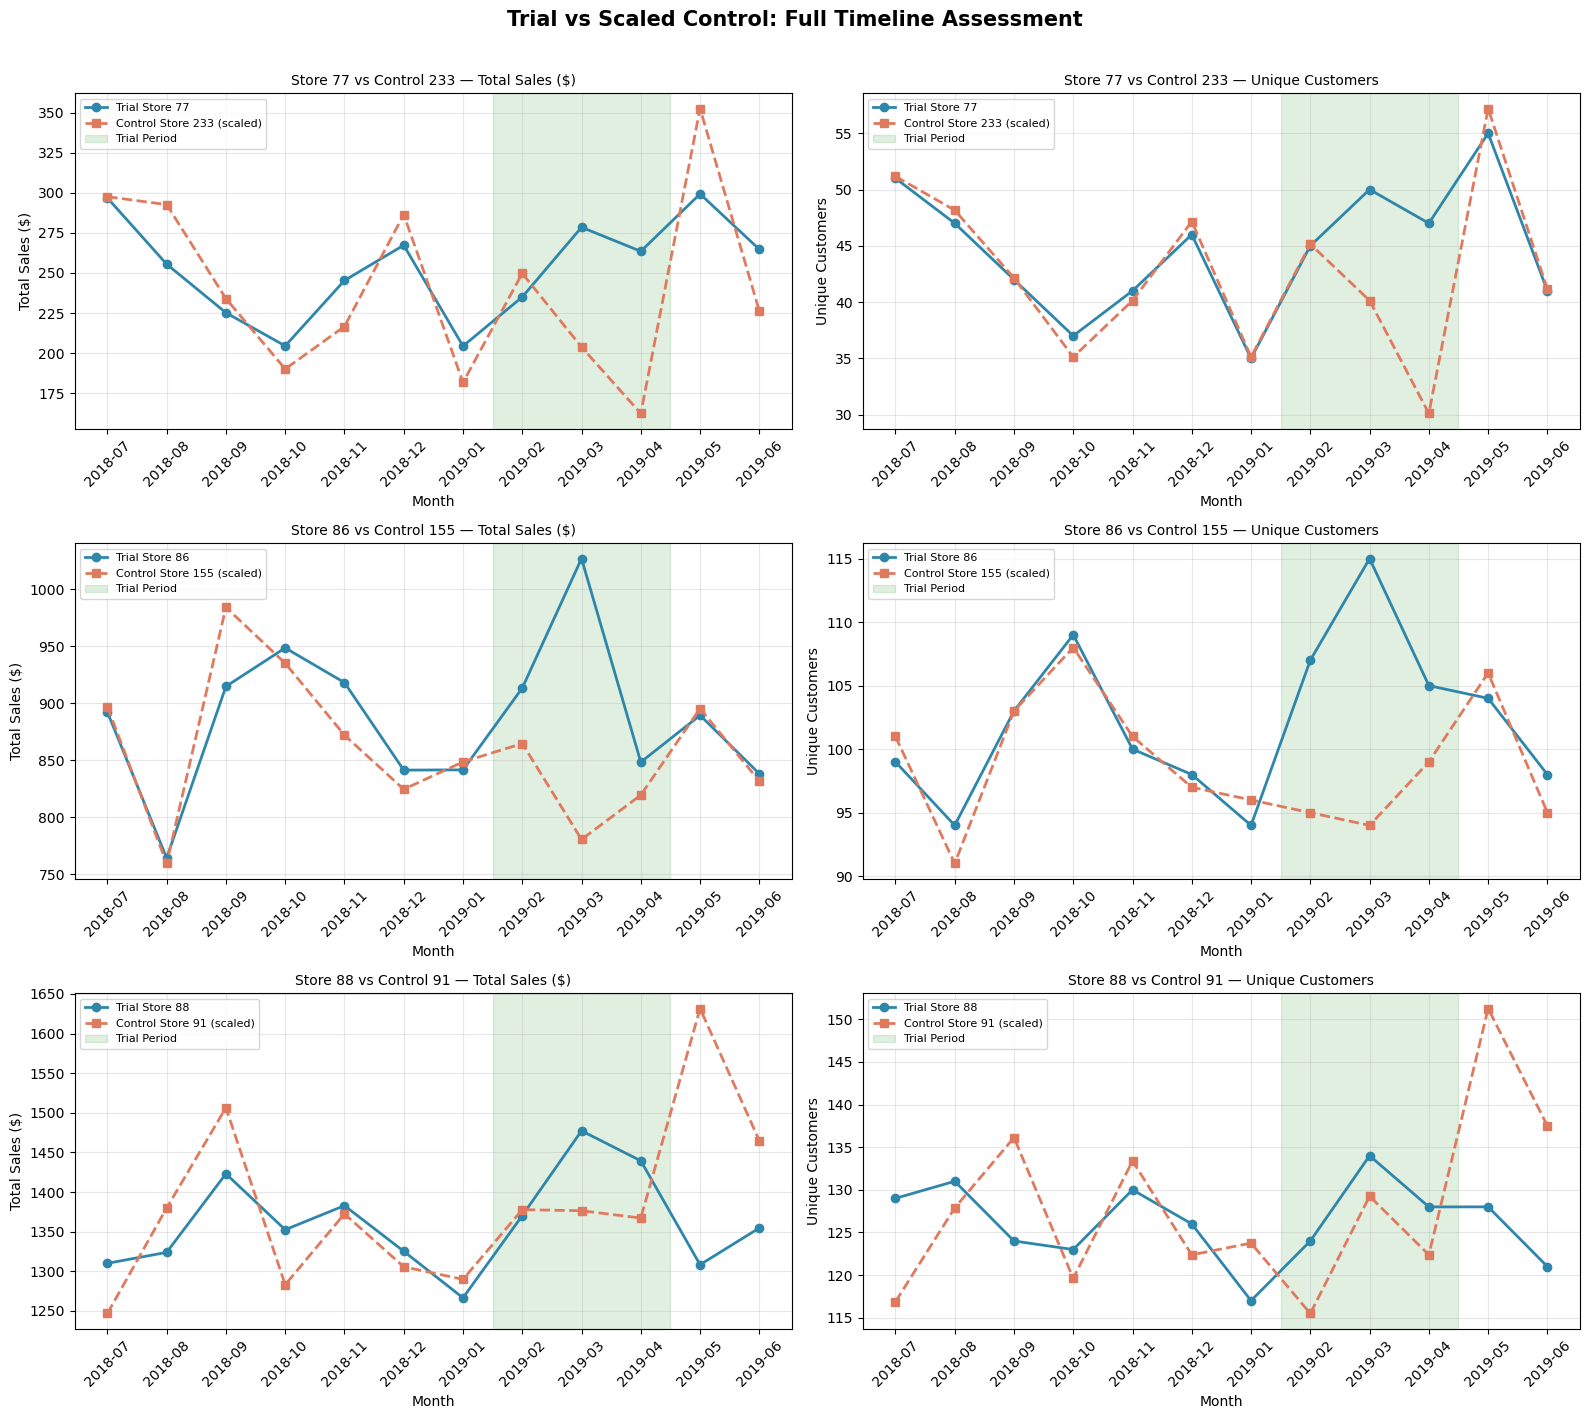

✅ Chart 3 saved: 03_full_timeline.png


In [17]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Trial vs Scaled Control: Full Timeline Assessment',
             fontsize=15, fontweight='bold', y=1.01)

for row, ts in enumerate(trial_stores):
    cs = control_map[ts]

    for col, (metric, label) in enumerate(metrics_to_plot):
        ax = axes[row, col]

        td = all_metrics[all_metrics['STORE_NBR'] == ts].sort_values('YEARMONTH')
        cd = all_metrics[all_metrics['STORE_NBR'] == cs].sort_values('YEARMONTH')

        # Scale control store to trial store's pre-trial size
        pre_t = td[td['YEARMONTH'] < TRIAL_START][metric].mean()
        pre_c = cd[cd['YEARMONTH'] < TRIAL_START][metric].mean()
        scale = pre_t / pre_c if pre_c > 0 else 1

        cd = cd.copy()
        cd[metric] = cd[metric] * scale

        months = td['YEARMONTH'].astype(str).tolist()

        # Plot both stores
        ax.plot(months, td[metric],
                marker='o', color=BLUE, lw=2, label=f'Trial Store {ts}')
        ax.plot(cd['YEARMONTH'].astype(str), cd[metric],
                marker='s', color=ORANGE, lw=2, linestyle='--',
                label=f'Control Store {cs} (scaled)')

        # Shade the trial period green
        trial_months = [m for m in months if '2019-02' <= m <= '2019-04']
        if trial_months:
            x0 = months.index(trial_months[0])
            x1 = months.index(trial_months[-1])
            ax.axvspan(x0 - 0.5, x1 + 0.5,
                       alpha=0.12, color='green', label='Trial Period')

        ax.set_title(f'Store {ts} vs Control {cs} — {label}', fontsize=10)
        ax.set_xlabel('Month')
        ax.set_ylabel(label)
        ax.legend(fontsize=8)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('visualisations/03_full_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved: 03_full_timeline.png")

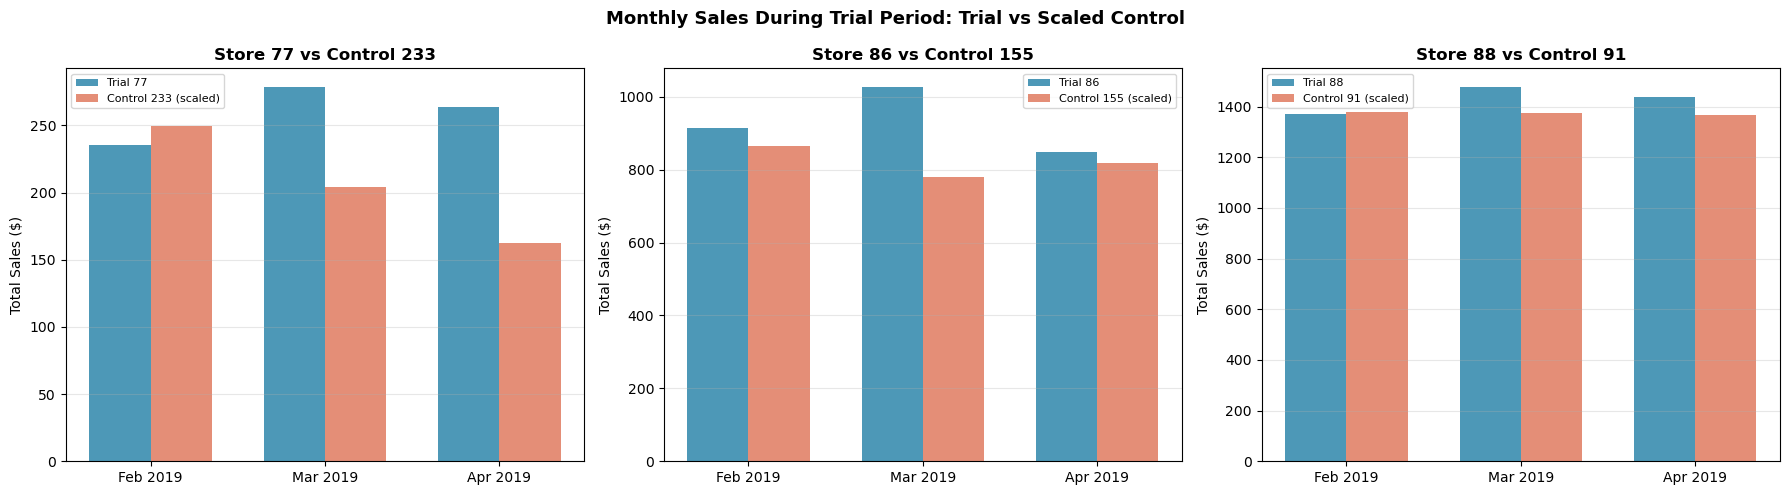

✅ Chart 4 saved: 04_monthly_trial_bars.png


In [18]:
trial_month_labels = ['Feb 2019', 'Mar 2019', 'Apr 2019']
trial_month_codes  = ['2019-02', '2019-03', '2019-04']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Monthly Sales During Trial Period: Trial vs Scaled Control',
             fontsize=13, fontweight='bold')

for i, ts in enumerate(trial_stores):
    cs = control_map[ts]
    ax = axes[i]

    td = all_metrics[all_metrics['STORE_NBR'] == ts].sort_values('YEARMONTH')
    cd = all_metrics[all_metrics['STORE_NBR'] == cs].sort_values('YEARMONTH')

    # Scale control
    pre_t = td[td['YEARMONTH'] < TRIAL_START]['total_sales'].mean()
    pre_c = cd[cd['YEARMONTH'] < TRIAL_START]['total_sales'].mean()
    cd = cd.copy()
    cd['total_sales'] = cd['total_sales'] * (pre_t / pre_c)

    # Filter to trial months
    td_t = td[td['YEARMONTH'].astype(str).isin(trial_month_codes)]
    cd_t = cd[cd['YEARMONTH'].astype(str).isin(trial_month_codes)]

    x = np.arange(len(trial_month_labels))
    w = 0.35

    ax.bar(x - w/2, td_t['total_sales'].values, w,
           label=f'Trial {ts}', color=BLUE, alpha=0.85)
    ax.bar(x + w/2, cd_t['total_sales'].values, w,
           label=f'Control {cs} (scaled)', color=ORANGE, alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(trial_month_labels)
    ax.set_title(f'Store {ts} vs Control {cs}', fontweight='bold')
    ax.set_ylabel('Total Sales ($)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('visualisations/04_monthly_trial_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved: 04_monthly_trial_bars.png")

In [20]:
print("\n" + "="*60)
print("UPLIFT & SIGNIFICANCE TESTING")
print("="*60)

results = {}

for ts in trial_stores:
    cs = control_map[ts]

    td = all_metrics[all_metrics['STORE_NBR'] == ts]
    cd = all_metrics[all_metrics['STORE_NBR'] == cs].copy()

    # Scale control store
    pre_t = td[td['YEARMONTH'] < TRIAL_START]['total_sales'].mean()
    pre_c = cd[cd['YEARMONTH'] < TRIAL_START]['total_sales'].mean()
    cd['total_sales'] = cd['total_sales'] * (pre_t / pre_c)

    # Filter to trial months only
    td_trial = td[td['YEARMONTH'].between(TRIAL_START, TRIAL_END)]['total_sales']
    cd_trial = cd[cd['YEARMONTH'].between(TRIAL_START, TRIAL_END)]['total_sales']

    # Calculate percentage uplift
    uplift = ((td_trial.mean() - cd_trial.mean()) / cd_trial.mean()) * 100

    # T-test for statistical significance
    t_stat, p_val = stats.ttest_ind(td_trial.values, cd_trial.values)

    results[ts] = {
        'control'     : cs,
        'uplift'      : round(uplift, 1),
        'p_value'     : round(p_val, 4),
        'significant' : p_val < 0.05,
        'trial_avg'   : round(td_trial.mean(), 2),
        'control_avg' : round(cd_trial.mean(), 2)
    }

    sig_label = "✅ SIGNIFICANT" if p_val < 0.05 else "⚠️  Not significant"
    print(f"\n  Trial Store {ts}  |  Control Store {cs}")
    print(f"    Trial avg sales   : ${td_trial.mean():,.2f}")
    print(f"    Control avg sales : ${cd_trial.mean():,.2f}")
    print(f"    Sales Uplift      : {uplift:+.1f}%")
    print(f"    p-value           : {p_val:.4f}  ({sig_label})")



UPLIFT & SIGNIFICANCE TESTING

  Trial Store 77  |  Control Store 233
    Trial avg sales   : $259.00
    Control avg sales : $205.30
    Sales Uplift      : +26.2%
    p-value           : 0.1305  (⚠️  Not significant)

  Trial Store 86  |  Control Store 155
    Trial avg sales   : $929.40
    Control avg sales : $821.39
    Sales Uplift      : +13.2%
    p-value           : 0.1339  (⚠️  Not significant)

  Trial Store 88  |  Control Store 91
    Trial avg sales   : $1,428.93
    Control avg sales : $1,373.75
    Sales Uplift      : +4.0%
    p-value           : 0.1547  (⚠️  Not significant)


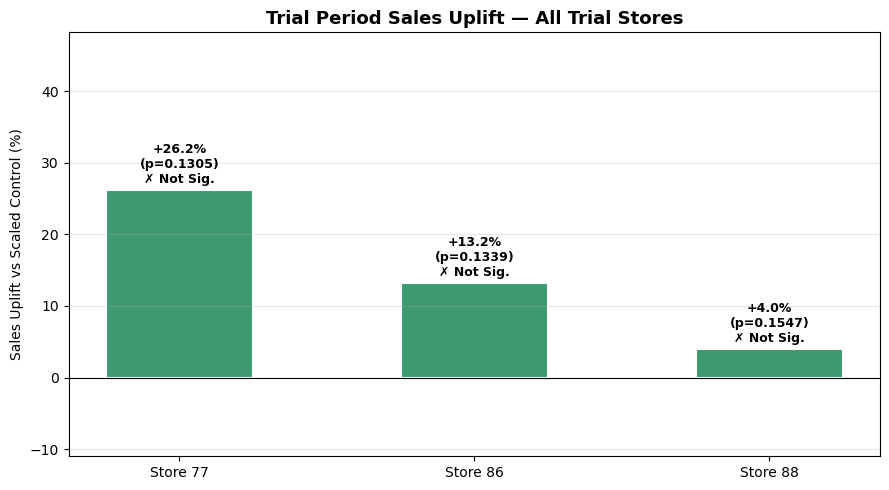

✅ Chart 5 saved: 05_uplift_summary.png


In [21]:
fig, ax = plt.subplots(figsize=(9, 5))

stores_labels = [f'Store {ts}' for ts in trial_stores]
uplifts       = [results[ts]['uplift'] for ts in trial_stores]
bar_colors    = [GREEN if u > 0 else RED for u in uplifts]

bars = ax.bar(stores_labels, uplifts,
              color=bar_colors, edgecolor='white', linewidth=1.5, width=0.5)

# Annotate each bar
for bar, ts in zip(bars, trial_stores):
    u   = results[ts]['uplift']
    p   = results[ts]['p_value']
    sig = '✓ Significant' if results[ts]['significant'] else '✗ Not Sig.'
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{u:+.1f}%\n(p={p})\n{sig}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Sales Uplift vs Scaled Control (%)')
ax.set_title('Trial Period Sales Uplift — All Trial Stores',
             fontsize=13, fontweight='bold')
ax.set_ylim(min(uplifts) - 15, max(uplifts) + 22)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('visualisations/05_uplift_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved: 05_uplift_summary.png")



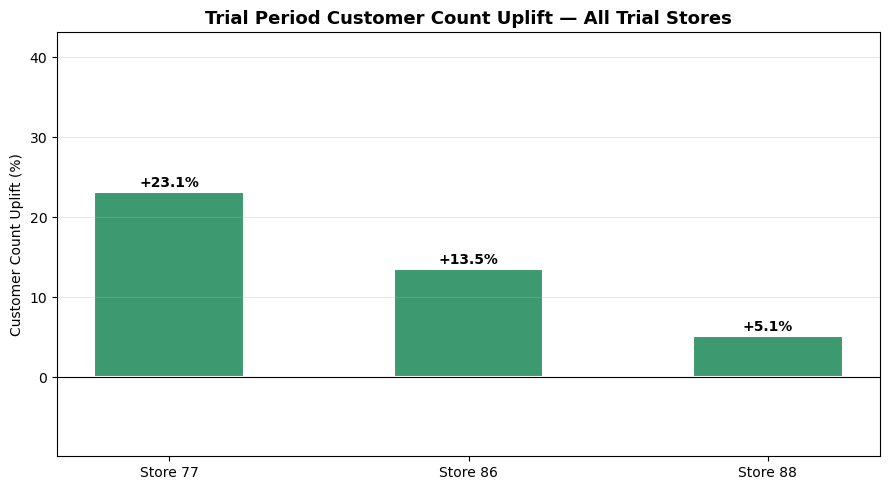

✅ Chart 6 saved: 06_customer_uplift.png


In [27]:
fig, ax = plt.subplots(figsize=(9, 5))

customer_uplifts = []
for ts in trial_stores:
    cs = control_map[ts]
    td = all_metrics[all_metrics['STORE_NBR'] == ts]
    cd = all_metrics[all_metrics['STORE_NBR'] == cs].copy()

    # Scale control on customers
    pre_t = td[td['YEARMONTH'] < TRIAL_START]['num_customers'].mean()
    pre_c = cd[cd['YEARMONTH'] < TRIAL_START]['num_customers'].mean()
    cd['num_customers'] = cd['num_customers'] * (pre_t / pre_c)

    td_t = td[td['YEARMONTH'].between(TRIAL_START, TRIAL_END)]['num_customers']
    cd_t = cd[cd['YEARMONTH'].between(TRIAL_START, TRIAL_END)]['num_customers']

    cu = ((td_t.mean() - cd_t.mean()) / cd_t.mean()) * 100
    customer_uplifts.append(round(cu, 1))

bar_colors2 = [GREEN if u > 0 else RED for u in customer_uplifts]
bars2 = ax.bar(stores_labels, customer_uplifts,
               color=bar_colors2, edgecolor='white', linewidth=1.5, width=0.5)

for bar, u in zip(bars2, customer_uplifts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{u:+.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Customer Count Uplift (%)')
ax.set_title('Trial Period Customer Count Uplift — All Trial Stores',
             fontsize=13, fontweight='bold')
ax.set_ylim(min(customer_uplifts) - 15, max(customer_uplifts) + 20)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('visualisations/06_customer_uplift.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved: 06_customer_uplift.png")

In [29]:
print("\n\n" + "="*65)
print("  QVI TRIAL STORE ANALYSIS — FINAL RESULTS SUMMARY")
print("="*65)

for ts, r in results.items():
    sig_label = "SIGNIFICANT (p < 0.05)" if r['significant'] else "Not significant"
    if r['uplift'] >= 20:
        rec = "STRONGLY recommend rollout"
    elif r['uplift'] >= 10:
        rec = "Recommend rollout"
    else:
        rec = "Monitor further before rollout"

    print(f"""
  ┌─────────────────────────────────────────────────────┐
  │  Trial Store {ts:<4}  vs  Control Store {r['control']:<4}             │
  ├─────────────────────────────────────────────────────┤
  │  Trial avg sales (monthly)  : ${r['trial_avg']:>10,.2f}          │
  │  Control avg sales (scaled) : ${r['control_avg']:>10,.2f}          │
  │  Sales Uplift               : {r['uplift']:>+10.1f}%          │
  │  p-value                    : {r['p_value']:>10.4f}           │
  │  Statistical significance   : {sig_label:<22}  │
  │  ─────────────────────────────────────────────────  │
  │  RECOMMENDATION: {rec:<34} │
  └─────────────────────────────────────────────────────┘""")

print("\n" + "="*65)
print("  VISUALISATIONS SAVED TO: ./visualisations/")
print("="*65)
print("  01_control_candidate_scores.png")
print("  02_pretrial_fit.png")
print("  03_full_timeline.png")
print("  04_monthly_trial_bars.png")
print("  05_uplift_summary.png")
print("  06_customer_uplift.png")
print("="*65)
print("\n✅ Analysis complete!\n")




  QVI TRIAL STORE ANALYSIS — FINAL RESULTS SUMMARY

  ┌─────────────────────────────────────────────────────┐
  │  Trial Store 77    vs  Control Store 233              │
  ├─────────────────────────────────────────────────────┤
  │  Trial avg sales (monthly)  : $    259.00          │
  │  Control avg sales (scaled) : $    205.30          │
  │  Sales Uplift               :      +26.2%          │
  │  p-value                    :     0.1305           │
  │  Statistical significance   : Not significant         │
  │  ─────────────────────────────────────────────────  │
  │  RECOMMENDATION: STRONGLY recommend rollout         │
  └─────────────────────────────────────────────────────┘

  ┌─────────────────────────────────────────────────────┐
  │  Trial Store 86    vs  Control Store 155              │
  ├─────────────────────────────────────────────────────┤
  │  Trial avg sales (monthly)  : $    929.40          │
  │  Control avg sales (scaled) : $    821.39          │
  │  Sales Uplift